In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from common import EVALUATE_ALL_CSVS

model = "EGFR_MAPK__logobs"
data = "dream_cytof"

filename = "evaluate_all_figure1b"
filename_px_tx = "evaluate_all_figure1b_recentered_proteomics_transcriptomics"

df = pd.read_csv(EVALUATE_ALL_CSVS.format(model=model, data=data, filename=filename), index_col=0)
print(df.shape)
df = df[~df.context.isin(["proteomics", "transcriptomics"])]
print(df.shape)
df_px_tx = pd.read_csv(EVALUATE_ALL_CSVS.format(model=model, data=data, filename=filename_px_tx), index_col=0)
print(df_px_tx.shape)
df = pd.concat([df, df_px_tx])
print(df.shape)

(7730, 16)
(4630, 16)
(3100, 16)
(7730, 16)


In [2]:
val_df = df[(df.dataset == "val") & (df.ref == "DMM")]
val_df.features.fillna("None", inplace=True)

In [3]:
val_df.groupby(["context", "features", "n_hidden", "depth", "l1reg_inflater_output", "l2reg_inflater_output"]).rmse.mean()

context          features           n_hidden  depth  l1reg_inflater_output  l2reg_inflater_output
cytof_init       RFE_10_permute     2.0       0.0    0.0000                 0.0000                   0.567245
                                                     0.0001                 0.0000                   0.562062
                                                     0.0010                 0.0000                   0.551483
                                                     0.0100                 0.0000                   0.527314
                                                                            0.0001                   0.527996
                                                                                                       ...   
transcriptomics  HVGRFE_20_permute  2.0       2.0    0.0100                 0.0000                   0.834470
                                              3.0    0.0100                 0.0000                   0.803665
                      

# n_hidden (fixed depth=0)

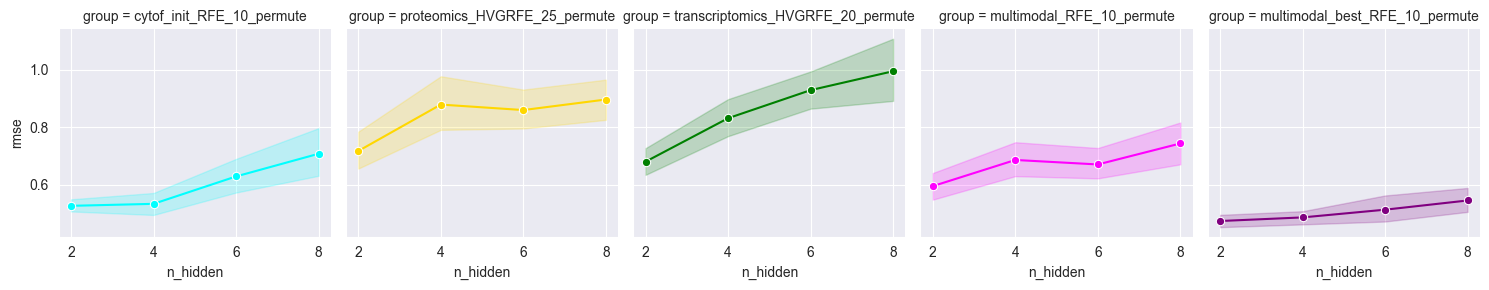

In [4]:
val_df["group"] = val_df["context"] + "_" + val_df["features"]

palette = {
    "cytof_init_RFE_10_permute": "cyan",
    "proteomics_HVGRFE_25_permute": "gold",
    "transcriptomics_HVGRFE_20_permute": "green",
    "multimodal_RFE_10_permute": "magenta",
    "multimodal_best_RFE_10_permute": "purple"
}

g = sns.FacetGrid(
    val_df[(val_df.depth == 0) & (val_df.l2reg_inflater_output == 0) & (val_df.l1reg_inflater_output == 1e-2)],
    col="group",
    col_order=palette.keys()
)

g.map_dataframe(
    sns.lineplot,
    x="n_hidden",
    y="rmse",
    marker='o',
    hue="group",
    palette=palette
)

In [5]:
from scipy import stats

def kruskal_wallis_groups(df, target_metric, group_metric, context_metric="context"):
    for context in df[context_metric].unique():
        context_data = df[df[context_metric] == context]
        groups = [group[target_metric].values for _, group in context_data.groupby(group_metric)]
        stat, p_value = stats.kruskal(*groups)
        print(f"Context/Group: {context} - Kruskal-Wallis H-test: H-statistic={stat:.2f}, p-value={p_value:.4f}, significant? {p_value < 0.05}")

In [6]:
kruskal_wallis_groups(
    val_df[(val_df.depth == 0) & (val_df.l2reg_inflater_output == 0) & (val_df.l1reg_inflater_output == 1e-2)],
    "rmse",
    "n_hidden",
    "group"
)

Context/Group: multimodal_best_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=5.07, p-value=0.1668, significant? False
Context/Group: multimodal_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=12.39, p-value=0.0062, significant? True
Context/Group: cytof_init_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=19.02, p-value=0.0003, significant? True
Context/Group: transcriptomics_HVGRFE_20_permute - Kruskal-Wallis H-test: H-statistic=36.19, p-value=0.0000, significant? True
Context/Group: proteomics_HVGRFE_25_permute - Kruskal-Wallis H-test: H-statistic=15.51, p-value=0.0014, significant? True


# No significant effect from `n_hidden` - if there is, it's clearly for the worse.

# depth (fixed n_hidden = 2)

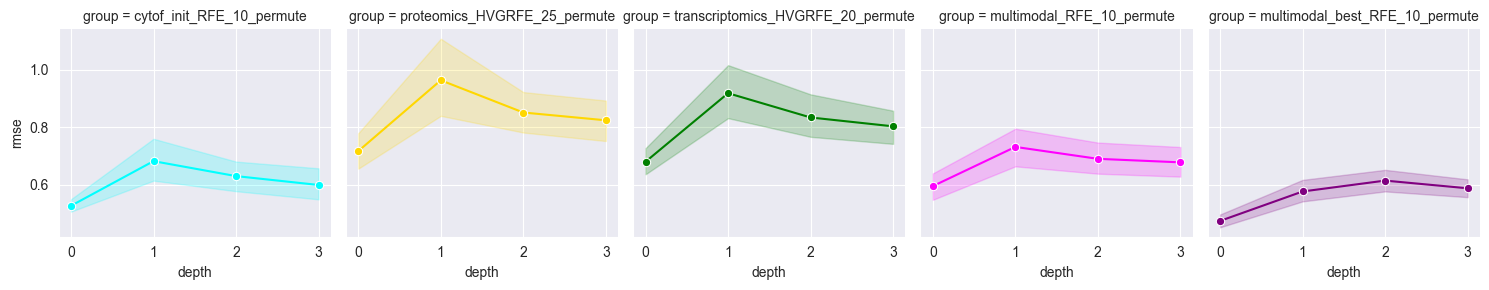

In [7]:
g = sns.FacetGrid(
    val_df[(val_df.n_hidden == 2) & (val_df.l2reg_inflater_output == 0) & (val_df.l1reg_inflater_output == 1e-2)],
    col="group",
    col_order=palette.keys(),
)

g.map_dataframe(
    sns.lineplot,
    x="depth",
    y="rmse",
    marker='o',
    hue="group",
    palette=palette
)

In [8]:
kruskal_wallis_groups(
    val_df[(val_df.n_hidden == 2) & (val_df.l2reg_inflater_output == 0) & (val_df.l1reg_inflater_output == 1e-2)],
    "rmse",
    "depth",
    "group"
)

Context/Group: multimodal_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=12.21, p-value=0.0067, significant? True
Context/Group: multimodal_best_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=35.65, p-value=0.0000, significant? True
Context/Group: cytof_init_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=15.83, p-value=0.0012, significant? True
Context/Group: transcriptomics_HVGRFE_20_permute - Kruskal-Wallis H-test: H-statistic=23.01, p-value=0.0000, significant? True
Context/Group: proteomics_HVGRFE_25_permute - Kruskal-Wallis H-test: H-statistic=10.48, p-value=0.0149, significant? True


# No significant effect from `depth`, if not for the worse for cytof_init and multimodal.

# `l1reg_inflater_output` (fixed `n_hidden`, `depth` and `l2reg_inflater_output`)

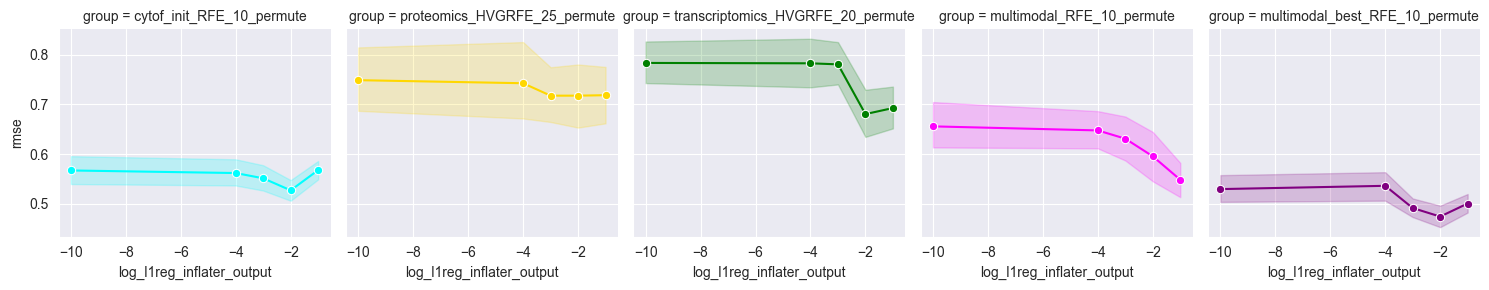

In [9]:
import numpy as np

val_df["log_l1reg_inflater_output"] = np.where(
    val_df["l1reg_inflater_output"] != 0,
    np.log10(val_df["l1reg_inflater_output"]),
    -10
)
g = sns.FacetGrid(
    val_df[(val_df.n_hidden == 2) & (val_df.depth == 0) & (val_df.l2reg_inflater_output == 0)],
    col="group",
    col_order=palette.keys(),
)

g.map_dataframe(
    sns.lineplot,
    x="log_l1reg_inflater_output",
    y="rmse",
    marker='o',
    hue="group",
    palette=palette
)

In [10]:
kruskal_wallis_groups(
    val_df[(val_df.n_hidden == 2) & (val_df.depth == 0) & (val_df.l2reg_inflater_output == 0)],
    "rmse",
    "log_l1reg_inflater_output",
    "group"
)

Context/Group: multimodal_best_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=18.09, p-value=0.0012, significant? True
Context/Group: multimodal_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=20.35, p-value=0.0004, significant? True
Context/Group: cytof_init_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=12.08, p-value=0.0167, significant? True
Context/Group: transcriptomics_HVGRFE_20_permute - Kruskal-Wallis H-test: H-statistic=23.21, p-value=0.0001, significant? True
Context/Group: proteomics_HVGRFE_25_permute - Kruskal-Wallis H-test: H-statistic=1.32, p-value=0.8572, significant? False


# Effect of `l1reg_inflater_output` seems to be significant for cytof and the multimodal contexts! But it goes back up after the optimal value in both cases (apart from multimodal not best)

# `l2reg_inflater_output` (fixed `n_hidden`, `depth` and `l1reg_inflater_output`)

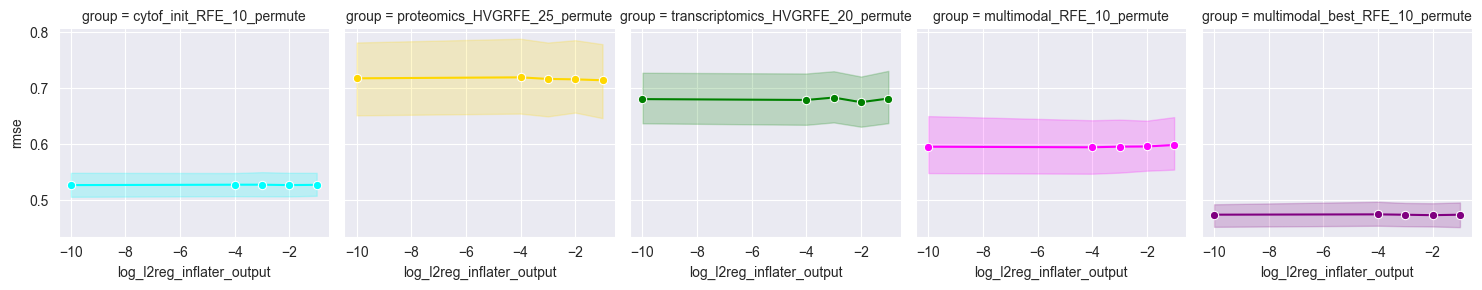

In [11]:
import numpy as np

val_df["log_l2reg_inflater_output"] = np.where(
    val_df["l2reg_inflater_output"] != 0,
    np.log10(val_df["l2reg_inflater_output"]),
    -10
)
g = sns.FacetGrid(
    val_df[(val_df.n_hidden == 2) & (val_df.depth == 0) & (val_df.l1reg_inflater_output == 1e-2)],
    col="group",
    col_order=palette.keys(),
)

g.map_dataframe(
    sns.lineplot,
    x="log_l2reg_inflater_output",
    y="rmse",
    marker='o',
    hue="group",
    palette=palette
)

In [12]:
kruskal_wallis_groups(
    val_df[(val_df.n_hidden == 2) & (val_df.depth == 0) & (val_df.l1reg_inflater_output == 1e-2)],
    "rmse",
    "log_l2reg_inflater_output",
    "group"
)

Context/Group: multimodal_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=0.08, p-value=0.9992, significant? False
Context/Group: multimodal_best_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=0.03, p-value=0.9999, significant? False
Context/Group: cytof_init_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=0.00, p-value=1.0000, significant? False
Context/Group: transcriptomics_HVGRFE_20_permute - Kruskal-Wallis H-test: H-statistic=0.13, p-value=0.9980, significant? False
Context/Group: proteomics_HVGRFE_25_permute - Kruskal-Wallis H-test: H-statistic=0.03, p-value=0.9999, significant? False


# No significant effect from `l2_reg_inflater_output` either...

# As best_RFE_10_permute outperforms RFE_10_permute for multimodal, we can subset to that feature selection strategy only and rather look at sample split

In [13]:
val_df = val_df[~((val_df["context"] == "multimodal") &
                  (val_df["features"] == "RFE_10_permute"))]

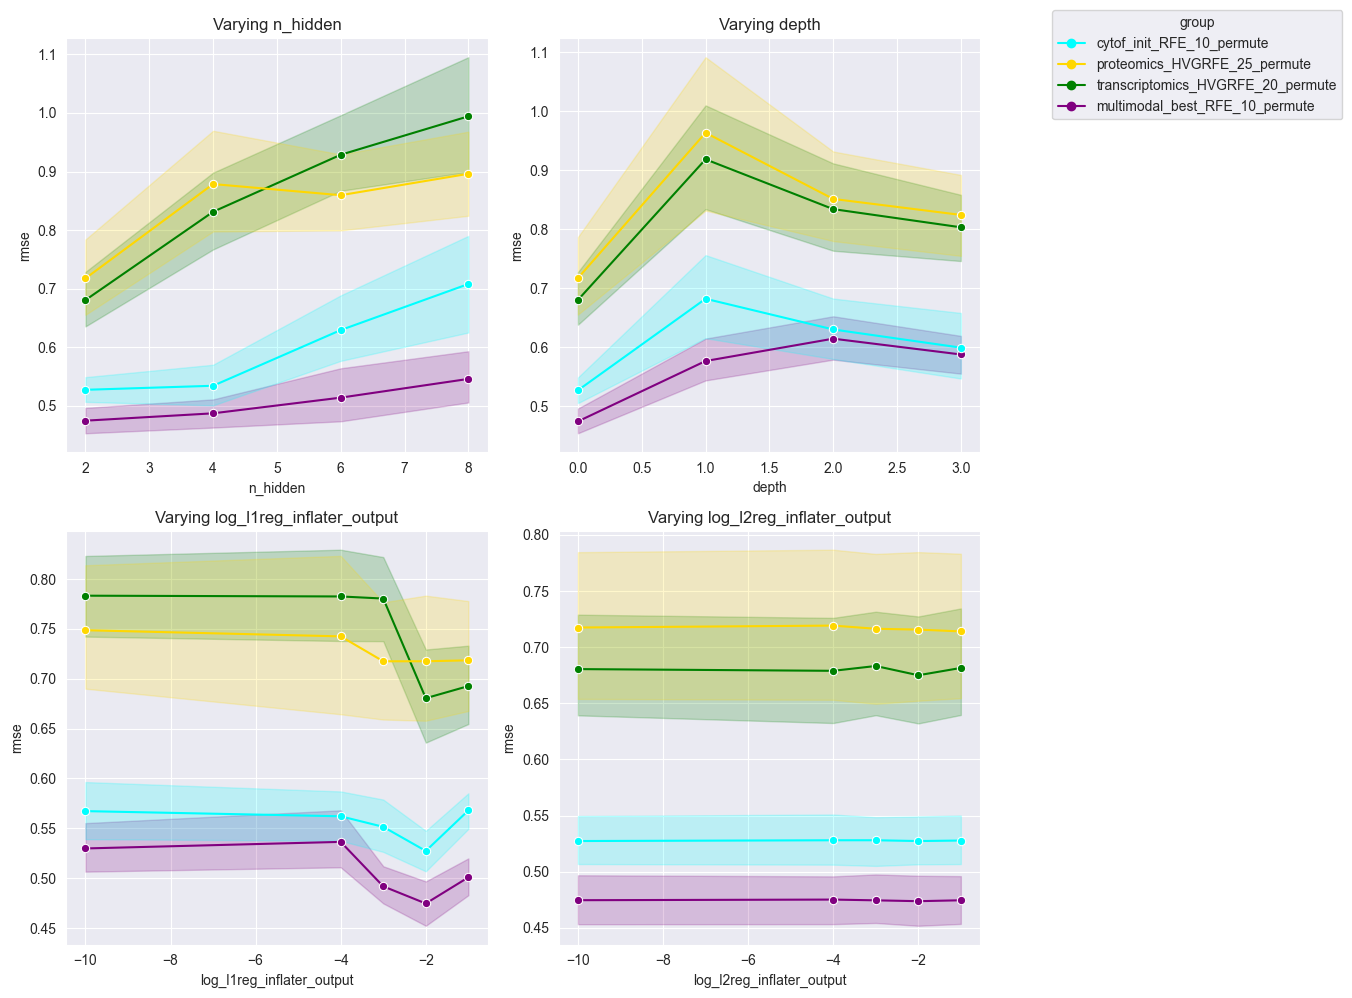

In [14]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

param_central_values = {
    "n_hidden": 2,
    "depth": 0,
    "log_l1reg_inflater_output": -2,
    "log_l2reg_inflater_output": -10,  # ~0
}

for i, param in enumerate(param_central_values.keys()):
    mask = np.ones(len(val_df), dtype=bool)
    for parameter, value in param_central_values.items():
        if parameter == param:
            continue
        mask &= val_df[parameter] == value

    ax = axes.flat[i]
    sns.lineplot(
        data=val_df[mask],
        x=param, y="rmse",
        hue="group",
        palette=palette,
        marker="o",
        legend=False,   # suppress subplot legends
        ax=ax,
    )
    ax.set_title(f"Varying {param}")

# --- build one shared legend using palette keys (keeps your order) ---
legend_labels = [group for group in list(palette.keys()) if group != "multimodal_RFE_10_permute"]
legend_handles = [Line2D([0], [0], marker='o', linestyle='-',
                         color=palette[label], label=label)
                  for label in legend_labels]

fig.legend(legend_handles, legend_labels, title="group",
           bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


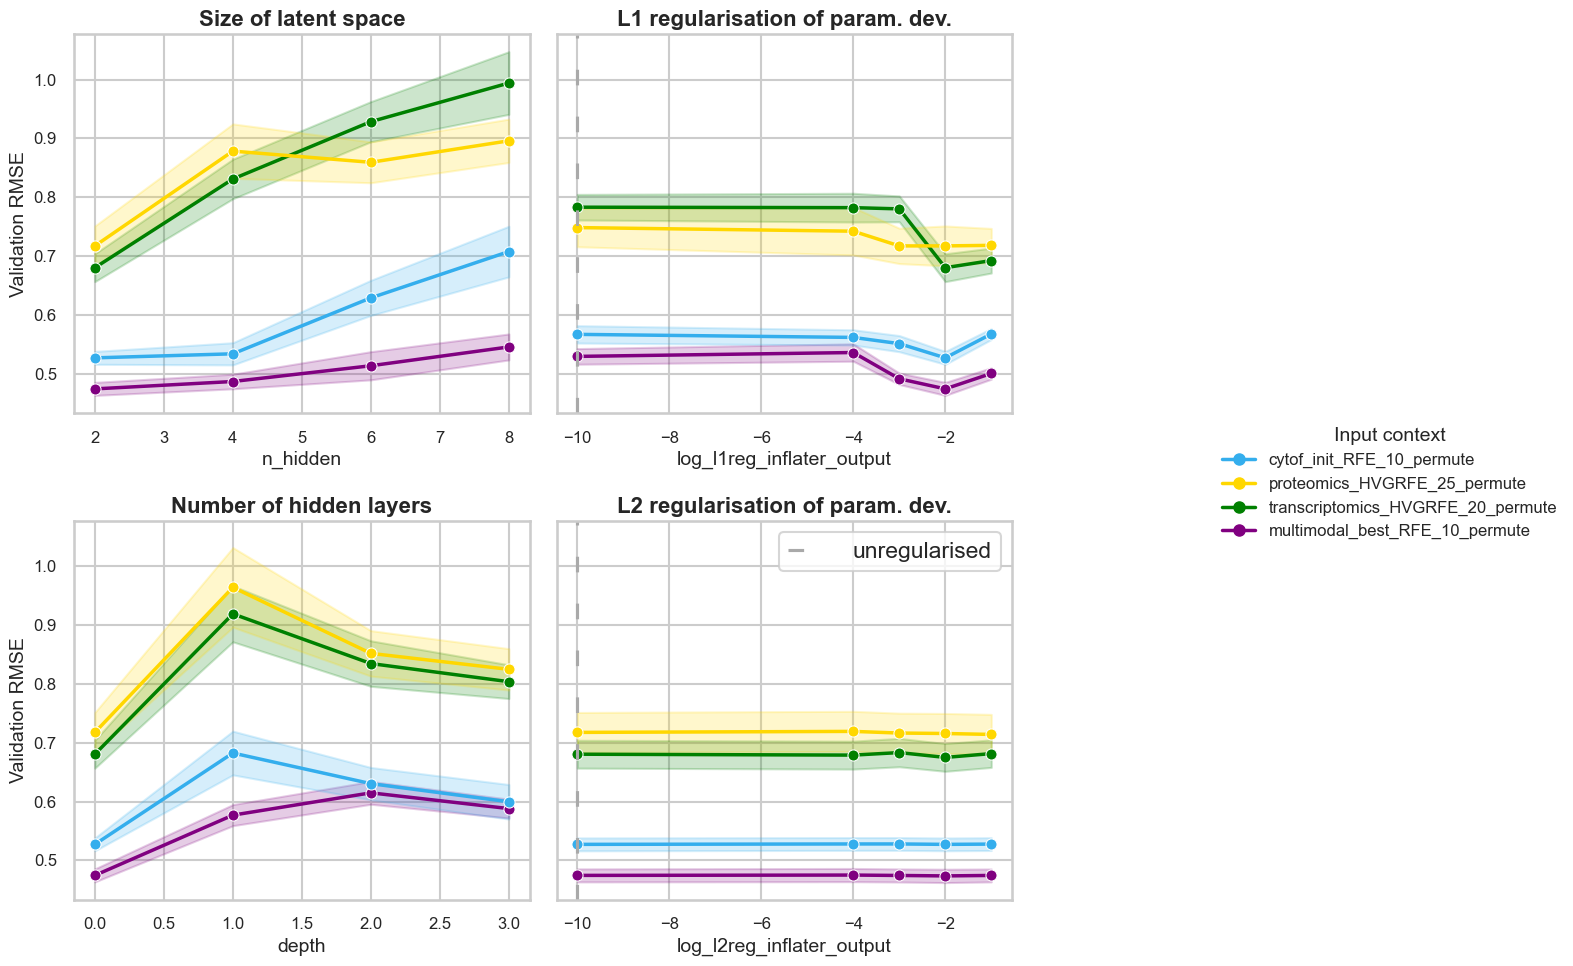

In [15]:
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import seaborn as sns

palette = {
    "cytof_init_RFE_10_permute": (52/255, 174/255, 237/255),
    "proteomics_HVGRFE_25_permute": "gold",
    "transcriptomics_HVGRFE_20_permute": "green",
    "multimodal_RFE_10_permute": "magenta",
    "multimodal_best_RFE_10_permute": "purple"
}

# Set a modern style
sns.set_theme(style="whitegrid", context="talk")

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey=True)

param_central_values = {
    "n_hidden": 2,
    "log_l1reg_inflater_output": -2,
    "depth": 0,
    "log_l2reg_inflater_output": -10,  # ~0
}

titles = {
    "n_hidden": "Size of latent space",
    "log_l1reg_inflater_output": "L1 regularisation of param. dev.",
    "depth":  "Number of hidden layers",
    "log_l2reg_inflater_output": "L2 regularisation of param. dev.",
}

for i, param in enumerate(param_central_values.keys()):
    mask = np.ones(len(val_df), dtype=bool)
    for parameter, value in param_central_values.items():
        if parameter == param:
            continue
        mask &= val_df[parameter] == value

    ax = axes.flat[i]
    sns.lineplot(
        data=val_df[mask],
        x=param, y="rmse",
        errorbar="se",
        hue="group",
        palette=palette,
        marker="o",
        linewidth=2.5,
        markersize=8,
        legend=False,   # suppress subplot legends
        ax=ax,
    )

    # Axis formatting
    ax.set_title(titles[param], fontsize=16, fontweight="bold")
    ax.set_xlabel(param, fontsize=14)
    ax.set_ylabel("Validation RMSE", fontsize=14)
    ax.tick_params(axis="both", which="major", labelsize=12)

    # Special annotation for -10 meaning ~0 regularisation
    if "log" in param:
        ax.axvline(
            -10,
            ls=(0, (5, 10)),
            label="unregularised",
            color="darkgray"
        )
        plt.legend()

# --- build one shared legend using palette keys (keeps your order) ---
legend_labels = [group for group in list(palette.keys()) if group != "multimodal_RFE_10_permute"]
legend_handles = [Line2D([0], [0], marker='o', linestyle='-',
                         color=palette[label], markersize=8, linewidth=2.5,
                         label=label)
                  for label in legend_labels]

fig.legend(legend_handles, legend_labels, title="Input context",
           bbox_to_anchor=(1.02, 0.5), loc="center left",
           frameon=False, fontsize=12, title_fontsize=14)

plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.savefig("scan_ML_params_recentered_SEerrorbars.svg")
plt.show()

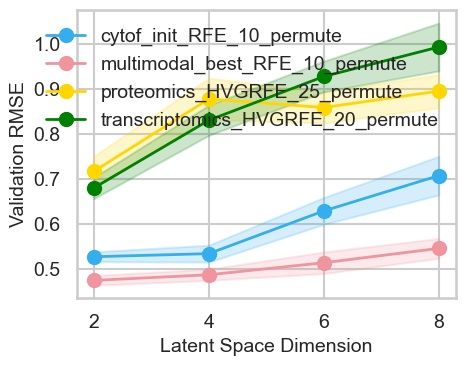

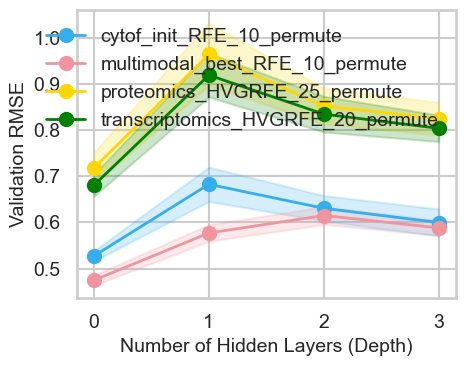

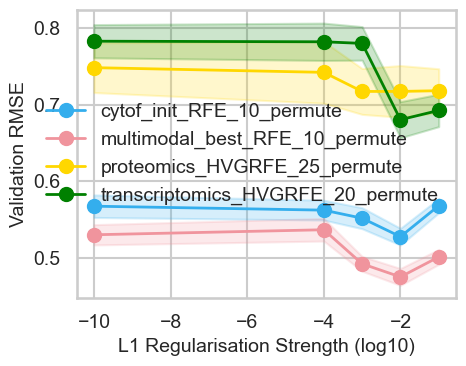

In [17]:
# --- requirements: matplotlib, numpy, pandas ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Central values for parameters not on the current x-axis
param_central_values = {
    "n_hidden": 2,
    "log_l1reg_inflater_output": -2,
    "depth": 0,
    "log_l2reg_inflater_output": -10,  # ~0
}

# Pretty x-axis labels
xlabels = {
    "n_hidden": "Latent Space Dimension",
    "depth": "Number of Hidden Layers (Depth)",
    "log_l1reg_inflater_output": "L1 Regularisation Strength (log10)",
}

def mask_for_param(df, vary_param):
    """Hold other params at central values while varying `vary_param`."""
    mask = np.ones(len(df), dtype=bool)
    for p, v in param_central_values.items():
        if p == vary_param:
            continue
        if p not in df.columns:
            raise KeyError(f"Expected column '{p}' in val_df but it was not found.")
        mask &= df[p] == v
    return mask

def mean_sem(df, group_col, x_col, y_col):
    """Compute mean and SEM for error bars."""
    g = df.groupby([group_col, x_col])[y_col].agg(['mean', 'sem']).reset_index()
    g.rename(columns={'mean': 'y', 'sem': 'yerr'}, inplace=True)
    return g

def plot_param(df, x_param, filename):
    # Filter to rows where all *other* params are at central values
    mask = mask_for_param(df, x_param)
    sub = df.loc[mask].copy()
    if sub.empty:
        raise ValueError(f"No rows found for {x_param} with other params fixed at central values.")

    # Aggregate for error bars
    agg = mean_sem(sub, 'group', x_param, 'rmse')

    # New figure (separate plot)
    plt.figure(figsize=(5, 4))

    # Plot each group (multimodal in coral, others default)
    for group, gdf in agg.groupby('group'):
        gdf = gdf.sort_values(x_param)
        color_dict = {
            "cytof_init_RFE_10_permute": (52/255, 174/255, 237/255),
            "proteomics_HVGRFE_25_permute": "gold",
            "transcriptomics_HVGRFE_20_permute": "green",
            "multimodal_best_RFE_10_permute": (240/255, 148/255, 157/255)
        }

        color = color_dict[group]
        plt.plot(
            gdf[x_param].to_numpy(),
            gdf['y'].to_numpy(),
            marker='o',
            markersize=10,
            linewidth=2,
            color=color,
            label=group,
        )
        plt.fill_between(
            gdf[x_param].to_numpy(),
            gdf['y'].to_numpy() - gdf['yerr'].to_numpy(),
            gdf['y'].to_numpy() + gdf['yerr'].to_numpy(),
            color=color,
            alpha=0.2,
        )

    # Labels and ticks (fontsize 14); no grid
    plt.xlabel(xlabels[x_param], fontsize=14)
    plt.ylabel("Validation RMSE", fontsize=14)
    plt.legend(fontsize=14, frameon=False)

    plt.tick_params(axis='both', which='both',
                direction='out', length=8, width=1.2, labelsize=14)
    plt.tight_layout()
    plt.savefig(filename, bbox_inches='tight', dpi=300)
    plt.show()

# --- Run the three requested plots (assumes `val_df` is defined) ---
plot_param(val_df, "n_hidden", "rmse_vs_n_hidden.svg")
plot_param(val_df, "depth", "rmse_vs_depth.svg")
plot_param(val_df, "log_l1reg_inflater_output", "rmse_vs_log_l1reg_inflater_output.svg")

|# Add Kruskal-Wallis stat tests

In [15]:
def p_to_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

def groupwise_kw(df, xcol, ycol, groupcol):
    results = {}
    for g, sub in df.groupby(groupcol):
        groups = [ys[ycol].values for _, ys in sub.groupby(xcol)]
        if len(groups) > 1:
            stat, p = stats.kruskal(*groups)
            results[g] = p
    return results

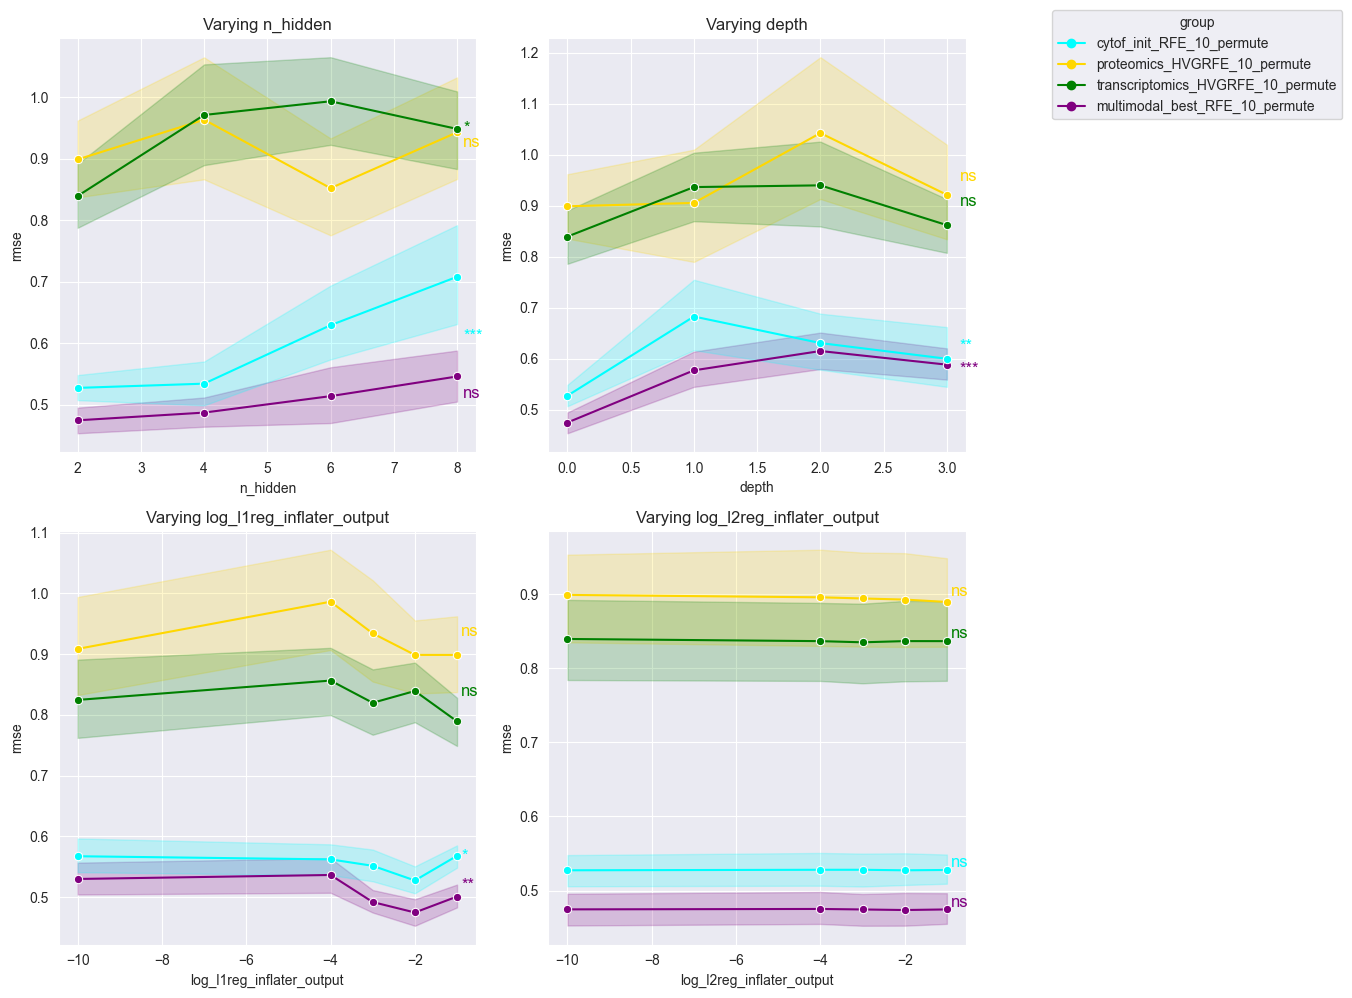

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

param_central_values = {
    "n_hidden": 2,
    "depth": 0,
    "log_l1reg_inflater_output": -2,
    "log_l2reg_inflater_output": -10,  # ~0
}

for i, param in enumerate(param_central_values.keys()):
    mask = np.ones(len(val_df), dtype=bool)
    for parameter, value in param_central_values.items():
        if parameter == param:
            continue
        mask &= val_df[parameter] == value

    ax = axes.flat[i]
    sns.lineplot(
        data=val_df[mask],
        x=param, y="rmse",
        hue="group",
        palette=palette,
        marker="o",
        legend=False,   # suppress subplot legends
        ax=ax,
    )
    ax.set_title(f"Varying {param}")

    dsub = val_df[mask]

    kw_results = groupwise_kw(dsub, xcol=param, ycol="rmse", groupcol="group")

    for g, p in kw_results.items():
        star = p_to_stars(p)
        x_pos = dsub[param].max() + 0.1
        y_pos = dsub.loc[dsub["group"] == g, "rmse"].mean()
        ax.text(
            x_pos,
            y_pos,
            star,
            color=palette[g],
            fontsize=12,
            ha="left", va="bottom"
        )

# --- build one shared legend using palette keys (keeps your order) ---
legend_labels = [group for group in list(palette.keys()) if group != "multimodal_RFE_10_permute"]
legend_handles = [Line2D([0], [0], marker='o', linestyle='-',
                         color=palette[label], label=label)
                  for label in legend_labels]

fig.legend(legend_handles, legend_labels, title="group",
           bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

The significance in `n_hidden` is lost if we subset to `n_hidden < 6` and is only significant for `cytof_init` if `n_hidden <= 6` (and for the worse) meaning the change we see in `multimodal` from 2 to 4 is not significant...

Completely flat vs l2reg_inflater_output? Mostly! Not identical values though, so at least it's not super worrying...

In [58]:
val_df[
    (val_df.n_hidden == 2) & (val_df.depth == 0) & (val_df.l1reg_inflater_output == 1e-2)
].groupby(["context", "features", "l2reg_inflater_output"]).rmse.mean()

context          features             l2reg_inflater_output
cytof_init       RFE_10_permute       0.0000                   0.527314
                                      0.0001                   0.527996
                                      0.0010                   0.528020
                                      0.0100                   0.527299
                                      0.1000                   0.527766
multimodal       best_RFE_10_permute  0.0000                   0.474607
                                      0.0001                   0.475161
                                      0.0010                   0.474490
                                      0.0100                   0.473728
                                      0.1000                   0.474537
proteomics       HVGRFE_10_permute    0.0000                   0.898709
                                      0.0001                   0.895481
                                      0.0010                   0.893910
    